In [1]:
import pandas as pd
from src.data import DATA_DIR_INTERIM

from src.io import load_qrels_from_path, read_metadata, load_qrel_from_path
from topic_gen.evaluate import MetaExperiment
from topic_gen.evaluate.io import load_from_irds
from topic_gen.evaluate.measures_agreement import CohenKappa, AreaUnderReceiver, MeanAverageError
from topic_gen.evaluate.measures_agreement_multiple import RosKTau, RosRBO, FleissKappa, KrippendorffAlpha
from topic_gen.evaluate.utils import QrelsTransformer


from topic_gen import logger
logger.setLevel("DEBUG")

In [1]:
import ir_measures

In [8]:
run=ir_measures.read_trec_qrels("../../topic-gen/tests/data/test-qrels-1.qrels")

In [9]:
for i in run:
    print(i)

Qrel(query_id='0', doc_id='D0', relevance=0, iteration='0')
Qrel(query_id='0', doc_id='D1', relevance=1, iteration='0')
Qrel(query_id='0', doc_id='D2', relevance=1, iteration='0')
Qrel(query_id='0', doc_id='D3', relevance=2, iteration='0')
Qrel(query_id='0', doc_id='D4', relevance=0, iteration='0')
Qrel(query_id='1', doc_id='D0', relevance=1, iteration='0')
Qrel(query_id='1', doc_id='D3', relevance=2, iteration='0')
Qrel(query_id='1', doc_id='D5', relevance=2, iteration='0')


# **Clarity:** How is the agreement between different generated qrels using the generated topics?

## Reference

### Graded Relevance Label
- Fleiss Kappa shows a moderate (>0.4) agreement across all five LLM annotators for the TREC topics.
- Krippendorff Alpha shows a clear tendency towards reliability

In [2]:
# BASE_DIR = DATA_DIR_INTERIM / "qrels-robust-topics-generated"
BASE_DIR = DATA_DIR_INTERIM / "dl19" / "qrels-dl19-reference"
metadata = read_metadata(BASE_DIR)

[topic_gen] [WARNING] (io.py:47) Metadata not found for result 2025-12-10_06:31:40, skipping...


In [3]:
meta_exp = MetaExperiment(
    experiments=load_qrels_from_path(BASE_DIR, replace_label_mapping={999:0}),
    measures=[FleissKappa(), KrippendorffAlpha(level_of_measurement="ordinal")],
    filter_qrels=True
)

Error loading experiment from 2025-12-10_06:31:40: [Errno 2] No such file or directory: '/workspaces/conf26-generating-topics/data/interim/dl19/qrels-dl19-reference/2025-12-10_06:31:40/qrels.csv.gz'


In [4]:
res = meta_exp.evaluate()

In [5]:
res

[MeasureResult(name='ALL', measure='FleissKappa', value=np.float64(0.4572622248163358), missing_topics=0, missing_qrels=0),
 MeasureResult(name='ALL', measure='KrippendorffAlpha', value=np.float64(0.7539694712877835), missing_topics=0, missing_qrels=0)]

# Generated Topics

In [6]:
BASE_DIR = DATA_DIR_INTERIM / "dl19" / "qrels-dl19-topics-generated"

In [7]:
metadata = read_metadata(BASE_DIR)

[topic_gen] [WARNING] (io.py:47) Metadata not found for result 2025-12-10_06:31:40, skipping...


In [8]:
metadata = metadata[metadata["topics_model"] != "human"]
metadata["topics_nqueries"] = metadata["topics_nqueries"].fillna(0)
metadata["topics_ndocspos"] = metadata["topics_ndocspos"].fillna(0)
metadata["topics_ndocsneg"] = metadata["topics_ndocsneg"].fillna(0)

metadata["group"] = metadata.apply(
    lambda row: f'{row["topics_model"]}_{row["topics_prompt"]}_{str(int(row["topics_nqueries"]))}_{str(int(row["topics_ndocspos"]))}_{str(int(row["topics_ndocsneg"]))}', axis=1)

In [9]:
res_all = []
n_rater = {}
for group, meta in metadata.groupby("group"):
    if len(meta["model"].to_list()) < 2:
        continue
    # print(sorted(meta["model"].to_list()))
    try:
        experiments = []
        for qrels_path in meta["date"]:
            exp = load_qrel_from_path(BASE_DIR / qrels_path, replace_label_mapping={999:0})
            experiments.append(exp)

        meta_exp = MetaExperiment(
            experiments=experiments,
            measures=[FleissKappa(), KrippendorffAlpha(level_of_measurement="ordinal")],
            filter_qrels=True
        )

        
        res = meta_exp.evaluate()
        for r in res:
            r = r._replace(name=group)
            res_all.append(r)
        
        n_rater[group] = len(experiments)
    except Exception as e:
        print(f"Error in group {group}: {e}")

In [10]:
df = pd.DataFrame(res_all)
df = df.pivot(index="name", columns="measure", values="value").reset_index()
df["n_rater"] = df["name"].apply(lambda x: n_rater.get(x))
df[["topics_model", "prompt", "nqueries", "ndocspos", "ndocsneg"]] = df["name"].str.split("_", expand=True)
df = df.drop(["name"], axis=1)

ValueError: Columns must be same length as key

In [ ]:
df[["topics_model", "prompt", "nqueries", "ndocspos", "ndocsneg", "FleissKappa", "KrippendorffAlpha", "n_rater"]].round(2)

measure,topics_model,prompt,nqueries,ndocspos,ndocsneg,FleissKappa,KrippendorffAlpha,n_rater
0,gpt-oss-20B,topic-docs-neg,0,0,1,0.55,0.73,2
1,gpt-oss-20B,topic-docs-neg,0,0,2,0.47,0.69,2
2,gpt-oss-20B,topic-docs-neg,0,0,3,0.64,0.83,2
3,gpt-oss-20B,topic-docs-pos,0,1,0,0.37,0.69,2
4,gpt-oss-20B,topic-docs-pos,0,2,0,0.35,0.66,2
5,gpt-oss-20B,topic-docs-pos,0,3,0,0.38,0.68,2
6,gpt-oss-20B,topic-docs-pos,0,4,0,0.32,0.65,2
7,gpt-oss-20B,topic-docs-pos,0,5,0,0.34,0.67,2
8,gpt-oss-20B,topic-query,1,0,0,0.32,0.66,2
9,qwen3-14B-no-think,topic-contrastive,0,1,1,0.36,0.67,2


## Do LLM judges favor topic generators?

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
BASE_DIR = DATA_DIR_INTERIM / "dl19" / "qrels-dl19-topics-generated"

experiments = load_qrels_from_path(
    BASE_DIR, binarize_qrels=2, drop_relevance_values=999)

baseline = load_from_irds("msmarco-passage/trec-dl-2019/judged", binarize_qrels=2)
baseline.qrels = QrelsTransformer.drop_relevance(
    baseline.qrels, drop_values=999)

Error loading experiment from 2025-12-10_12:40:15: [Errno 2] No such file or directory: '/workspaces/conf26-generating-topics/data/interim/dl19/qrels-dl19-topics-generated/2025-12-10_12:40:15/qrels.csv.gz'
Error loading experiment from 2025-12-10_06:31:40: [Errno 2] No such file or directory: '/workspaces/conf26-generating-topics/data/interim/dl19/qrels-dl19-topics-generated/2025-12-10_06:31:40/qrels.csv.gz'


In [ ]:
meta_exp = MetaExperiment(
    experiments=experiments,
    baseline=baseline,
    measures=[CohenKappa(), AreaUnderReceiver(), MeanAverageError()],
    filter_qrels=True
)

In [ ]:
res = meta_exp.evaluate()

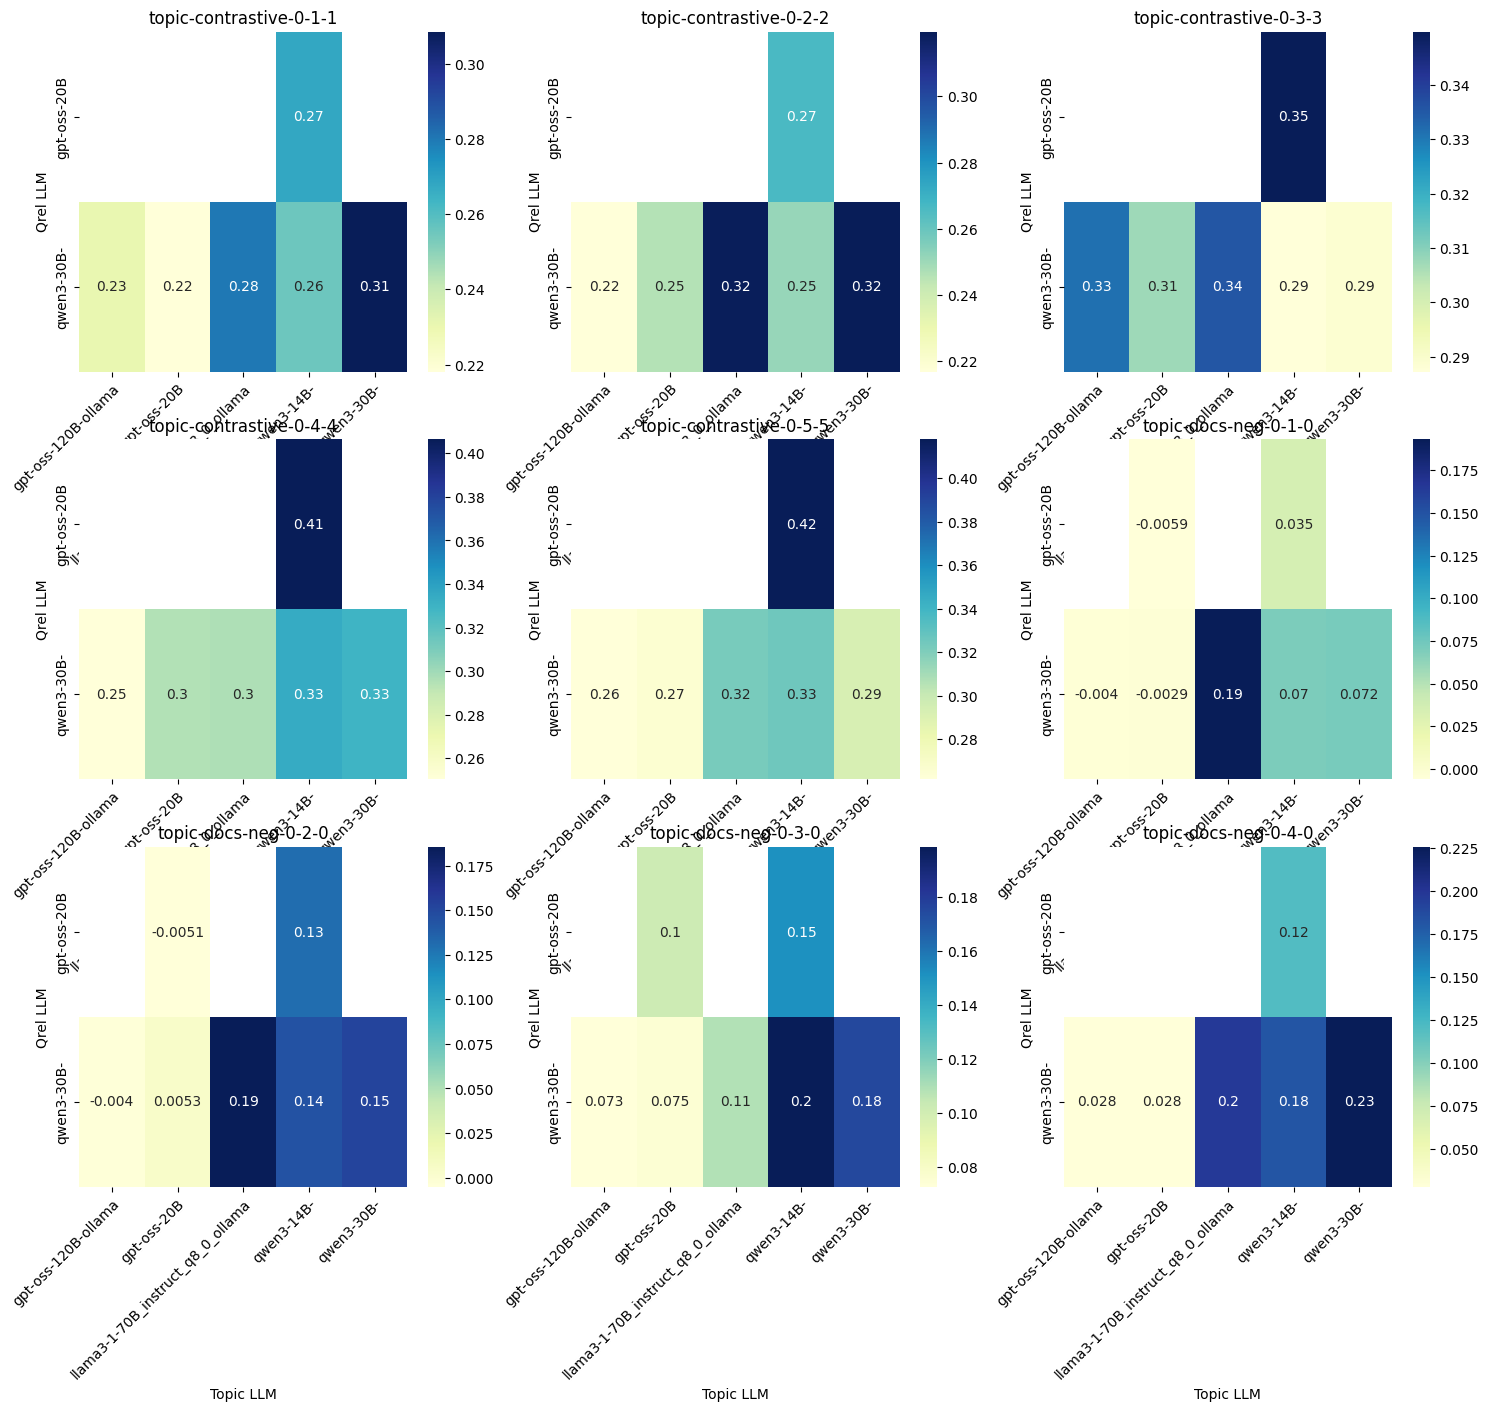

In [ ]:
tab = pd.DataFrame(res)
# df["score"] = df.apply(format_score, axis=1)
tab = tab.pivot(index="name", columns="measure", values="value").reset_index()
tab = tab.merge(metadata, left_on="name", right_on="date")

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes_flat = axes.flatten()

groups = tab.groupby(by=["prompt", "topics_prompt",
                       "topics_nqueries", "topics_ndocsneg", "topics_ndocspos"])

for ax, (key, df) in zip(axes_flat, groups):
    df = df.copy()

    row = df.iloc[0]
    name = row["topics_prompt"] + \
        "-" + str(int(row["topics_nqueries"])) + \
        "-" + str(int(row["topics_ndocsneg"])) + \
        "-" + str(int(row["topics_ndocspos"]))

    # df["CohenKappa"] = df["CohenKappa"].apply(
    #     lambda x: float(str(x).split(" ± ")[0]))
    df["model"] = df["model"].str.replace("no-think", "")
    df["topics_model"] = df["topics_model"].str.replace("no-think", "")
    df_pivot = df[["name", "CohenKappa", "model", "topics_model"]].pivot(
        index="model",
        columns="topics_model",
        values="CohenKappa"
    )

    sns.heatmap(df_pivot,
                annot=True,
                cmap='YlGnBu',
                ax=ax,
                # vmin=0.5,
                # vmax=0.8
                )
    # rotate x labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    ax.set_xlabel('Topic LLM')
    ax.set_ylabel('Qrel LLM')
    ax.set_title(name)

if len(groups) < len(axes_flat):
    for i in range(len(groups), len(axes_flat)):
        fig.delaxes(axes_flat[i])